# MC Injection Trials

In [23]:
import multiprocessing as mp
from functools import partial
from dataclasses import dataclass
from itertools import product

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import DMdecay as dmd
import JWSTutils as jwst
from gnz11_split import partition_gnz11

Load GNz-11 (arxiv v1) data 

In [9]:
run_dir = "gnz11_split"
prev_config_path = F"{run_dir}/gnz11_split.toml"

In [10]:
prev_configs = dmd.prep.parse_configs(prev_config_path)
run_name = prev_configs["run"]["name"]

data = jwst.process_datafiles(prev_configs["run"]["paths"], 
                                prev_configs["system"]["res_path"])
data = partition_gnz11(data, prev_configs["run"]["lambda_min"],
                        prev_configs["run"]["lambda_split"])
for spec in data:
    dmd.prep.doppler_correction(spec, prev_configs["halo"])
    dmd.prep.add_Dfactor(spec, prev_configs["halo"])
    spec["sigma_v"] = prev_configs["halo"]["sigma_v"]

base_specset = dmd.prep.SpecSetfromList(data)

parsing gnz11_split/gnz11_split.toml
processing 2 datafiles...


In [11]:
old_rawlimits = np.loadtxt(
    F"{run_name}/{prev_configs['run']['rawlimits_filename']}")
old_is_valid = np.isfinite(old_rawlimits[:, 1])
old_masses = old_rawlimits[old_is_valid, :][:, 0]
old_lam0s = dmd.conversions.mass_to_wavelength(old_masses)
exisitng_limit_invsec = old_rawlimits[old_is_valid, :][:, 1]
old_decayrates = \
    dmd.conversions.invsec_to_fluxscale(exisitng_limit_invsec)

In [12]:
keys_for_linesearch = {
    "analysis":[
      "width_factor", 
      "padding", 
      "num_knots", 
      "chisq_step", 
      "limit_guess", 
      "max_clip_iters", 
      "clipping_factor", 
      "Ntrials", 
      "Nbins", 
      "power_threshold"],
    "halo":[ 
      "sigma_v"]}
linesearch_configs = {k:prev_configs[k1][k] 
                       for k1, l1 in keys_for_linesearch.items()
                       for k in l1
                       if k in prev_configs[k1].keys()} 
linesearch_configs["num_knots"] = 4
linesearch_configs["width_factor"] = 20
setup = dmd.linesearch.LineSearchSetup(**linesearch_configs)

In [17]:
n_lam_test = 25
dr_factors = [0.1, 100]
n_dr_test = 10
chisq_step = 4

In [21]:
i_to_test = np.random.choice(np.arange(old_lam0s.size), 
                             n_lam_test,
                             replace=False)
lam0s_to_test = old_lam0s[i_to_test]
r = np.random.rand(n_dr_test, n_lam_test)
decayrates_to_test = old_decayrates[i_to_test]*dr_factors[0] + \
                     old_decayrates[i_to_test]*dr_factors[1]*r
decayrates_to_test = decayrates_to_test.T

print(lam0s_to_test.shape)
print(decayrates_to_test.shape)

(25,)
(25, 10)


In [19]:
bf_output = np.full(decayrates_to_test.shape, np.nan)
ci_output = np.full((*decayrates_to_test.shape, 2), np.nan)

iteration = product(range(n_lam_test), range(n_dr_test))
for i_lam0, i_dr in tqdm(iteration, total=n_lam_test*n_dr_test):
        # find initial chisq to scale errors
        trial_specset = base_specset.add_DM_line(dr, lam0)
        search = dmd.linesearch.LineSearcher(setup, trial_specset, lam0)
        search.fit_continuum_plus_line() 
        chisq = search.chisq(search.bf_knot_vals, search.bf_decay_rate)
        chisq_dof = chisq/search.dof_continuum_plus_line
        scaled_trial_specset = trial_specset.rescale_error(np.sqrt(chisq_dof))
        # fit scaled spectrum
        scaled_search = dmd.linesearch.LineSearcher(setup,
                                                    scaled_trial_specset, 
                                                    lam0)
        scaled_search.fit_continuum_plus_line() 
        bf_output[i_lam0, i_dr] = scaled_search.bf_decay_rate
        ci_output[i_lam0, i_dr, :] = \
            scaled_search.decayrate_ci_from_chisq(chisq_step) 

IndexError: index 10 is out of bounds for axis 0 with size 10

fit 0.0006 line at 1.45

example fit using default:
  Chisq/dof: 19.785140110233712
372
[[       nan        nan]
 [1.32976262 1.57023738]]
[[0.20346855 0.19396803 0.1871399  0.18091248 0.18455313]]
0
[0.00235407 0.00140402]

example fit using narrow:
  Chisq/dof: 42.92152968149285
44
[[       nan        nan]
 [1.43396835 1.46603165]]
[[0.20781861 0.17653199 0.21141985 0.21165725 0.17613955 0.18277513]]
0
[0.00235407 0.00140402]



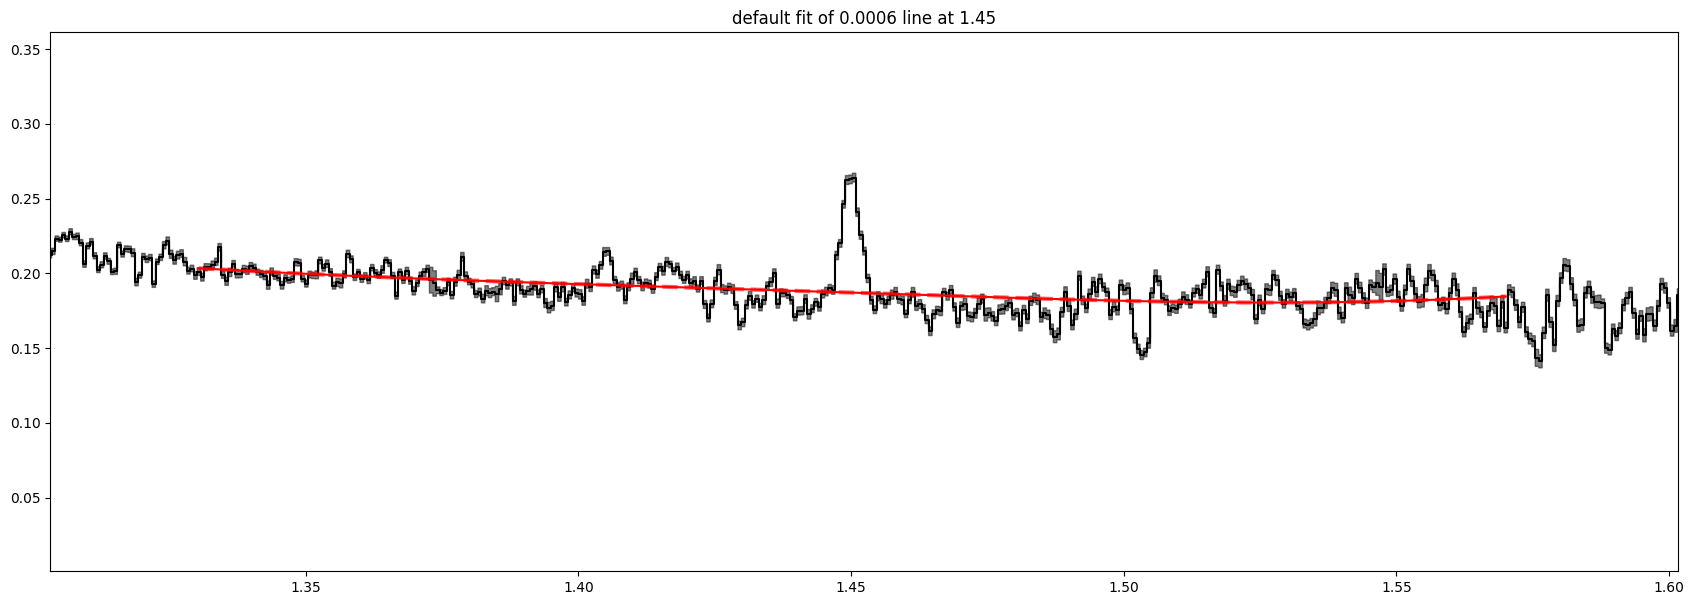

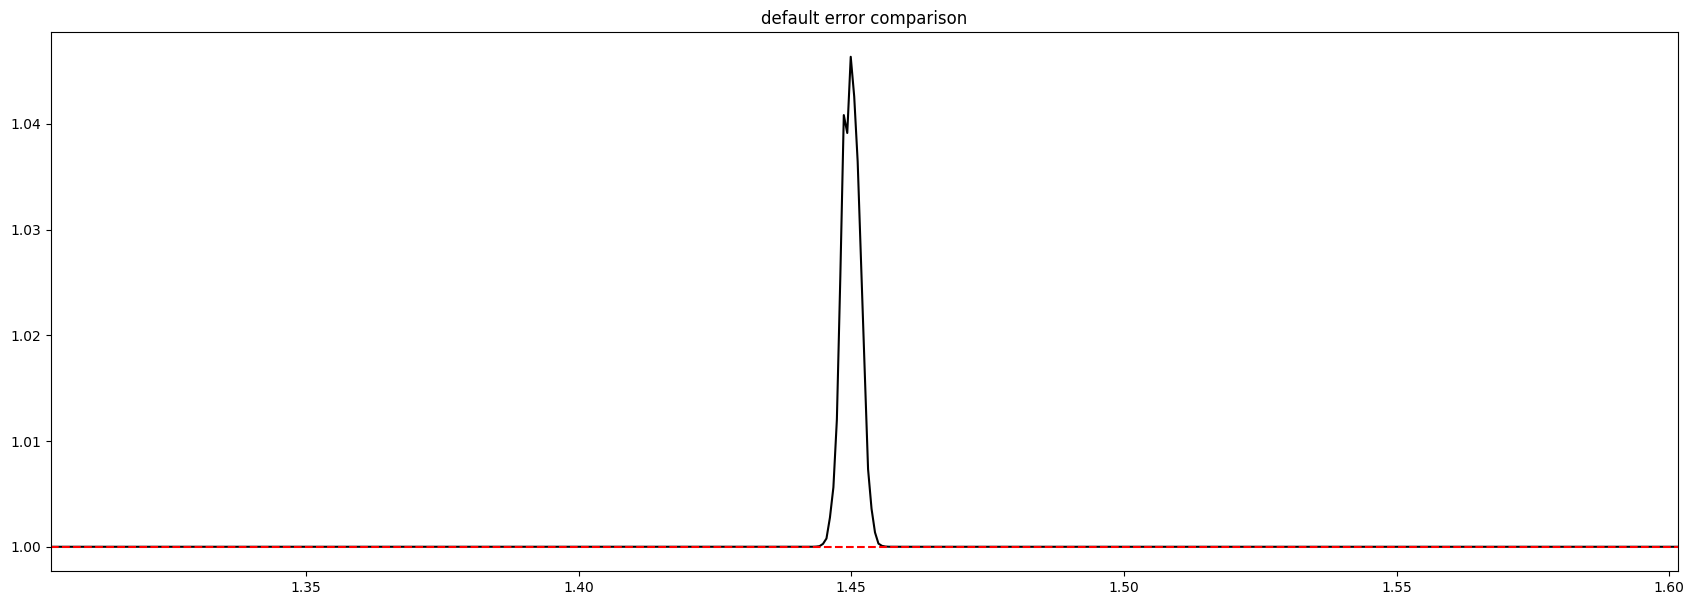

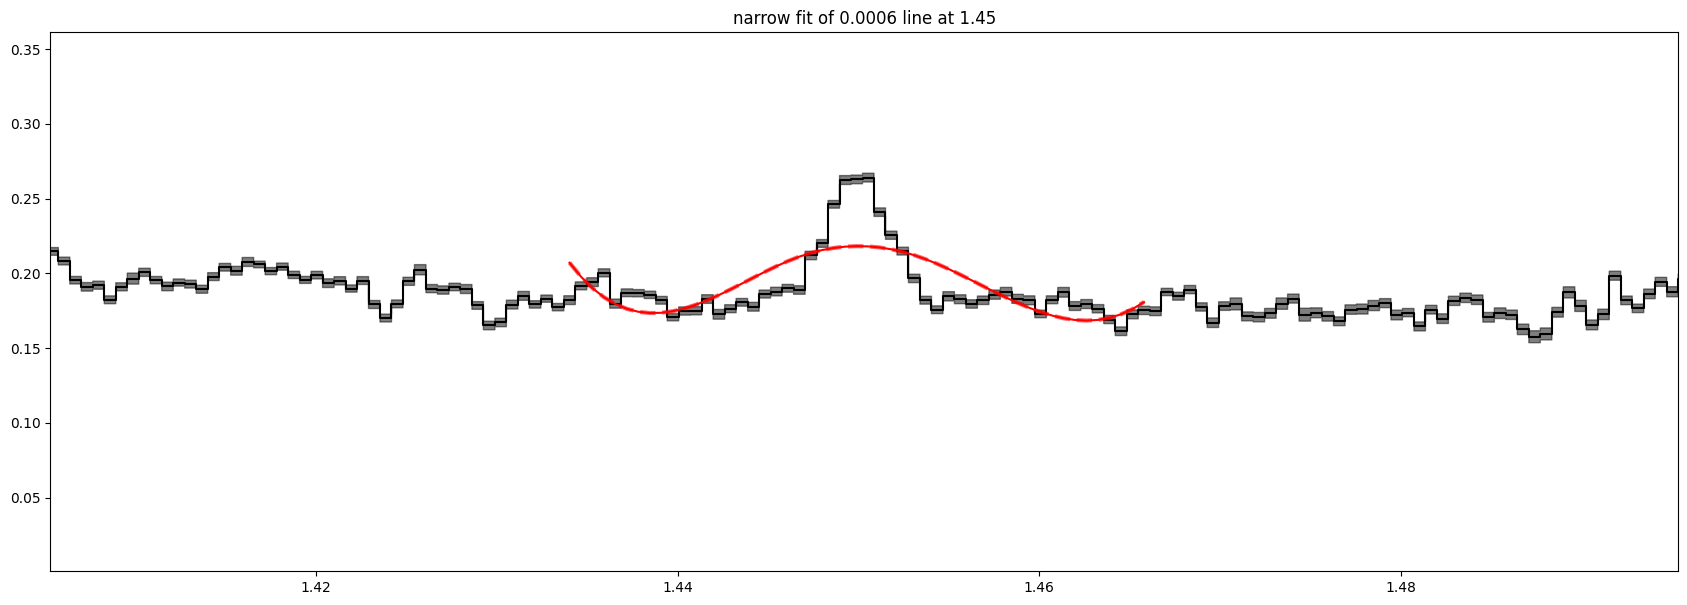

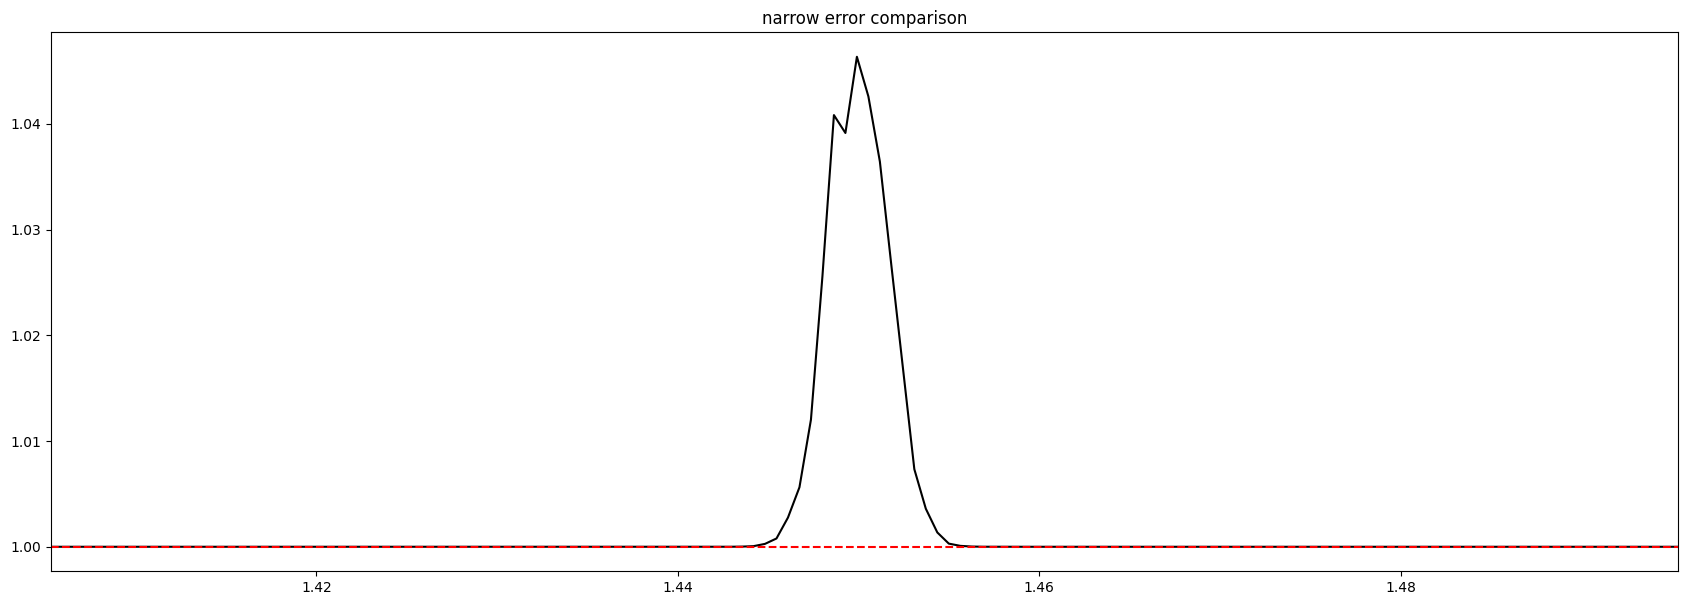

In [19]:
testing = np.array([[1.45, 2.1, 2.8], 
                    [6e-4, 1e-4, 1e-4]])
lam0, decayrate = testing[:, 0]
print(f"fit {decayrate} line at {lam0}\n")

for name, setup in setups.items():
    print(f"example fit using {name}:")
    new_specset = base_specset.add_DM_line(decayrate, lam0)\
                            #   .resample_flux()
    searcher = dmd.linesearch.LineSearcher(setup, new_specset, lam0)
    eg_knot_vals = searcher.fit_continuum_only()
    eg_decayrate = 0
    # eg_knot_vals, eg_decayrate = searcher.fit_continuum_plus_line()
    chisq_dof = \
        searcher.chisq(eg_knot_vals, eg_decayrate)/ \
        searcher.dof_continuum_plus_line
    print(f"  Chisq/dof: {chisq_dof}")
    print(searcher.dof_continuum_plus_line)
    print(f"{searcher.fit_intervals}")
    print(f"{eg_knot_vals}")
    print(f"{eg_decayrate}")
    print(searcher.data.inst_res)
    print()
    
    fig, ax = plt.subplots(figsize=(21, 7))
    new_specset.plot(ax=ax, error_band=0.5, color='black', alpha=1)
    model = searcher.spline_plus_line_model(eg_knot_vals, eg_decayrate, 
                                            searcher.lams_to_fit)
    model_continuum_only = searcher.spline_plus_line_model(eg_knot_vals, 0,
                                                        searcher.lams_to_fit)
    for i_model, i_specs in enumerate(searcher.to_fit):
        ax.plot(searcher.lams_to_fit[i_specs], model[i_model], color="red")
        ax.plot(searcher.lams_to_fit[i_specs], model_continuum_only[i_model], 
                color="red", alpha=0.6, linewidth=3, linestyle='dashed')
    ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
    ax.set_title(F"{name} fit of {decayrate} line at {lam0}")

    fig, ax = plt.subplots(figsize=(21, 7))
    for i in range(new_specset.N_specs):
        ax.plot(base_specset.lam[i], 
                new_specset.error[i]/base_specset.error[i], color='black')
    ax.axhline(1, color='red', linestyle='dashed')
    ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
    ax.set_title(F"{name} error comparison")


0.00022492567596457756


Text(0.5, 1.0, 'narrow fit of 0.0006 line at 1.45')

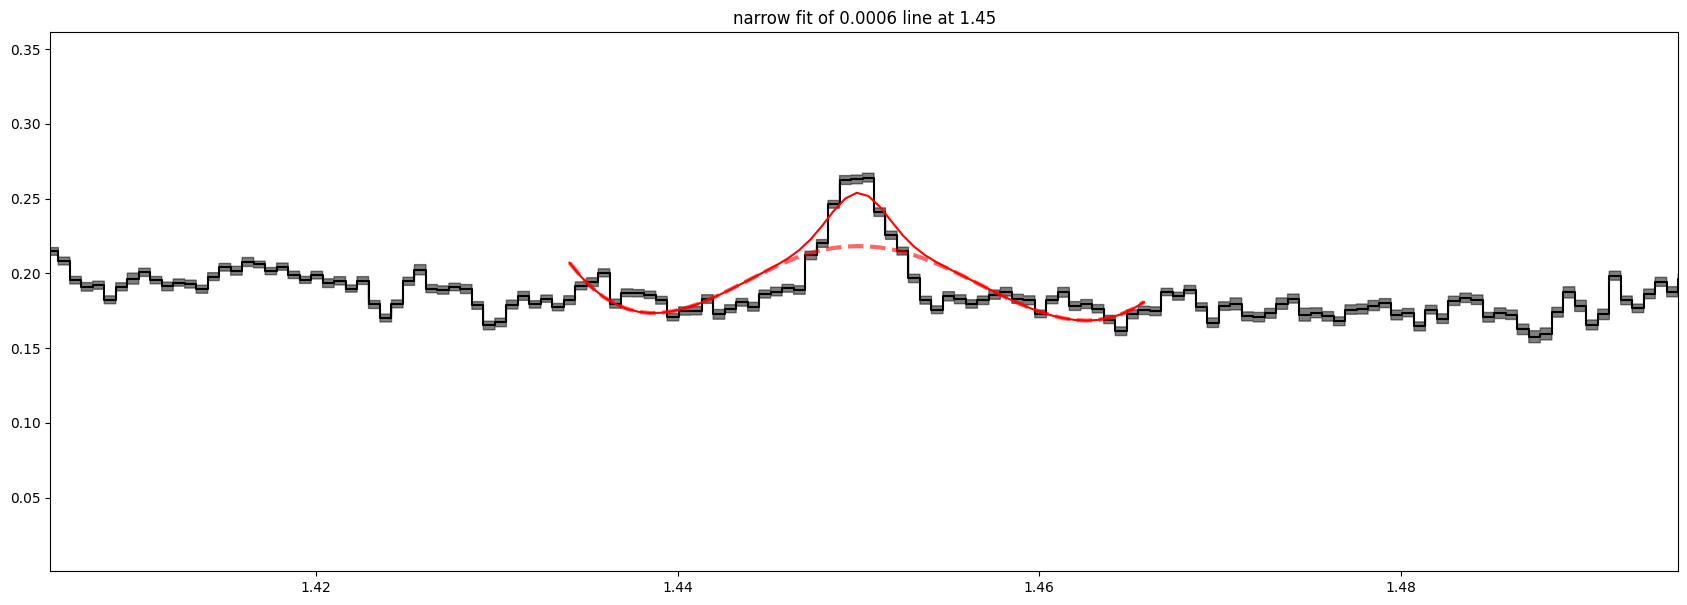

In [20]:
eg_decayrate = searcher.fit_line_only(eg_knot_vals)
print(eg_decayrate)

fig, ax = plt.subplots(figsize=(21, 7))
new_specset.plot(ax=ax, error_band=0.5, color='black', alpha=1)
model = searcher.spline_plus_line_model(eg_knot_vals, eg_decayrate, 
                                        searcher.lams_to_fit)
model_continuum_only = searcher.spline_plus_line_model(eg_knot_vals, 0,
                                                    searcher.lams_to_fit)
for i_model, i_specs in enumerate(searcher.to_fit):
    ax.plot(searcher.lams_to_fit[i_specs], model[i_model], color="red")
    ax.plot(searcher.lams_to_fit[i_specs], model_continuum_only[i_model], 
            color="red", alpha=0.6, linewidth=3, linestyle='dashed')
ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
ax.set_title(F"{name} fit of {decayrate} line at {lam0}")

0.0005391747193097693
4.299518960833395


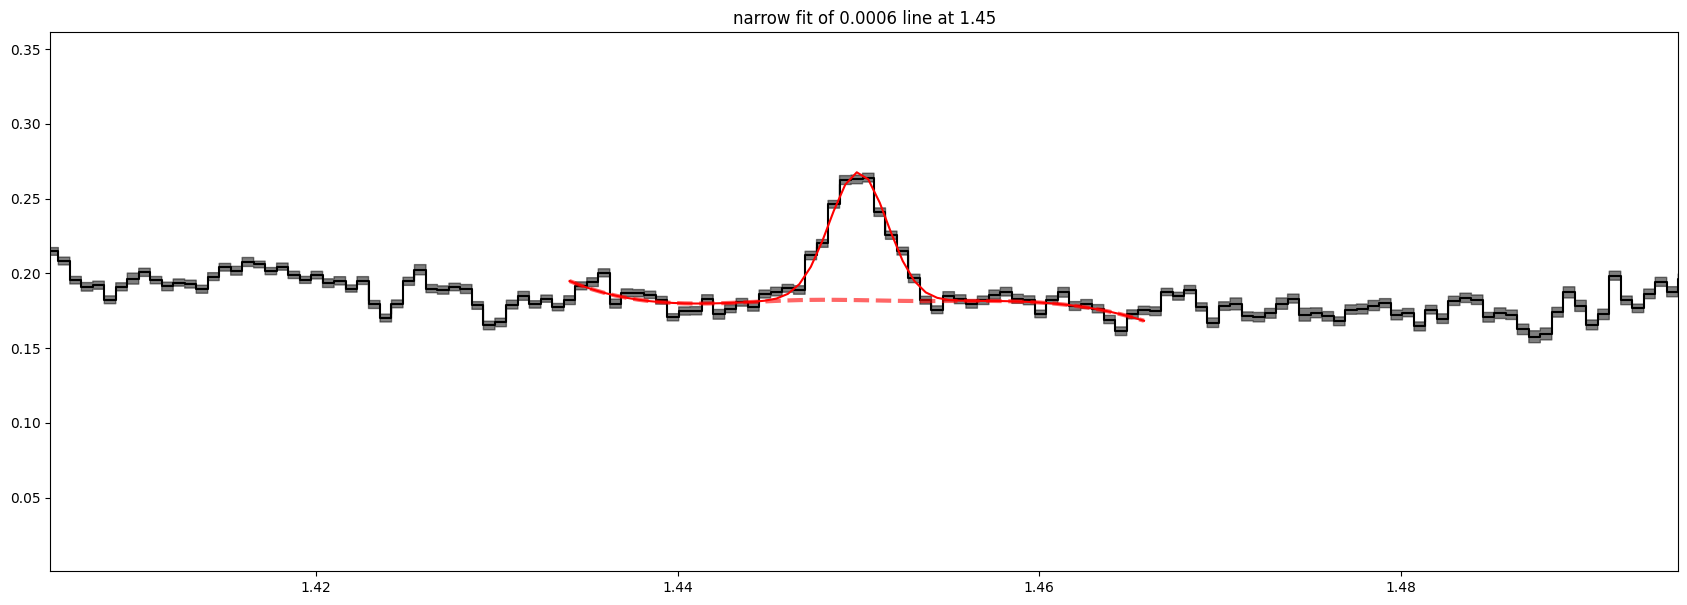

In [21]:
eg_knot_vals, eg_decayrate = searcher.fit_continuum_plus_line()
print(eg_decayrate)

fig, ax = plt.subplots(figsize=(21, 7))
new_specset.plot(ax=ax, error_band=0.5, color='black', alpha=1)
model = searcher.spline_plus_line_model(eg_knot_vals, eg_decayrate, 
                                        searcher.lams_to_fit)
model_continuum_only = searcher.spline_plus_line_model(eg_knot_vals, 0,
                                                    searcher.lams_to_fit)
for i_model, i_specs in enumerate(searcher.to_fit):
    ax.plot(searcher.lams_to_fit[i_specs], model[i_model], color="red")
    ax.plot(searcher.lams_to_fit[i_specs], model_continuum_only[i_model], 
            color="red", alpha=0.6, linewidth=3, linestyle='dashed')
ax.set_xlim(*searcher.get_plot_limits(margin=0.02))
ax.set_title(F"{name} fit of {decayrate} line at {lam0}")

chisq_dof = \
    searcher.chisq(eg_knot_vals, eg_decayrate)/ \
    searcher.dof_continuum_plus_line
print(chisq_dof)

In [22]:
print(searcher.bf_decay_rate)
print(searcher.bf_knot_vals)
print(searcher.decayrate_ci_from_chisq(4))

new_searcher = dmd.linesearch.LineSearcher(
    narrow_setup, 
    searcher.data.rescale_error(chisq_dof), 
    lam0)
print(new_searcher.decayrate_ci_from_chisq(4))

0.0005391747193097693
[[0.19507663 0.1798824  0.18209664 0.18145895 0.18074036 0.16733742]]
[0.00052228 0.00055607]
[0.00046653 0.00061182]


In [23]:
n_trials = 10**3
chisq_step = 4
error_scales = np.array([1, np.sqrt(chisq_dof)])
bf_decayrates_dict = {
    setup_name:np.full((n_trials, error_scales.size), np.nan)
    for setup_name in setups.keys()}
ci_dict = {
    setup_name:np.full((error_scales.size, 2), np.nan)
    for setup_name in setups.keys()}
for setup_name, setup in setups.items():
    for i, scale_factor in enumerate(error_scales):
        trial_specset = base_specset.add_DM_line(decayrate, lam0)\
                                    .rescale_error(scale_factor)
        search = dmd.linesearch.LineSearcher(setup, trial_specset, lam0)
        ci_dict[setup_name][i] = search.decayrate_ci_from_chisq(chisq_step) 
        for j in tqdm(range(n_trials)):
            trial_search = dmd.linesearch.LineSearcher(
                setup, trial_specset.resample_flux(), lam0)
            _, bf_decayrate = trial_search.fit_continuum_plus_line()
            bf_decayrates_dict[setup_name][j, i] = bf_decayrate

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [01:05<00:00, 15.37it/s]


In [24]:
print(f"input decayrate: {decayrate:.2e}\n")

med = {setup_name:np.median(bf_decayrates, axis=0)
       for setup_name, bf_decayrates in bf_decayrates_dict.items()}
sigma = {setup_name:(ci_dict[setup_name][1, :] - ci_dict[setup_name][0, :])/2
         for setup_name in med.keys()}
diff_width = {
    setup_name:np.abs(med[setup_name] - decayrate)/sigma[setup_name]
    for setup_name in med.keys()}

input decayrate: 6.00e-04



In [25]:
for setup_name in bf_decayrates_dict:
    print(F"{setup_name} results:")
    for i, scale_factor in enumerate(error_scales):
        print(f"  with error scaling {scale_factor:.2f}:\n"
            f"      output decayrate: "
            f"{ci_dict[setup_name][i][0]:.2e}  "
            f"{med[setup_name][i]:.2e}  " 
            f"{ci_dict[setup_name][i][1]:.2e}\n")
    print()

default results:
  with error scaling 1.00:
      output decayrate: 5.29e-04  5.46e-04  5.62e-04

  with error scaling 2.07:
      output decayrate: 5.10e-04  5.45e-04  5.81e-04


narrow results:
  with error scaling 1.00:
      output decayrate: 5.22e-04  5.39e-04  5.56e-04

  with error scaling 2.07:
      output decayrate: 5.04e-04  5.39e-04  5.74e-04




default, scale 1.00,
  frac inside ci: 95.20%

default, scale 2.07,
  frac inside ci: 93.20%

narrow, scale 1.00,
  frac inside ci: 79.40%

narrow, scale 2.07,
  frac inside ci: 80.20%



Text(0.5, 0.98, 'injection recovery: 6.00e-04 line at 1.45')

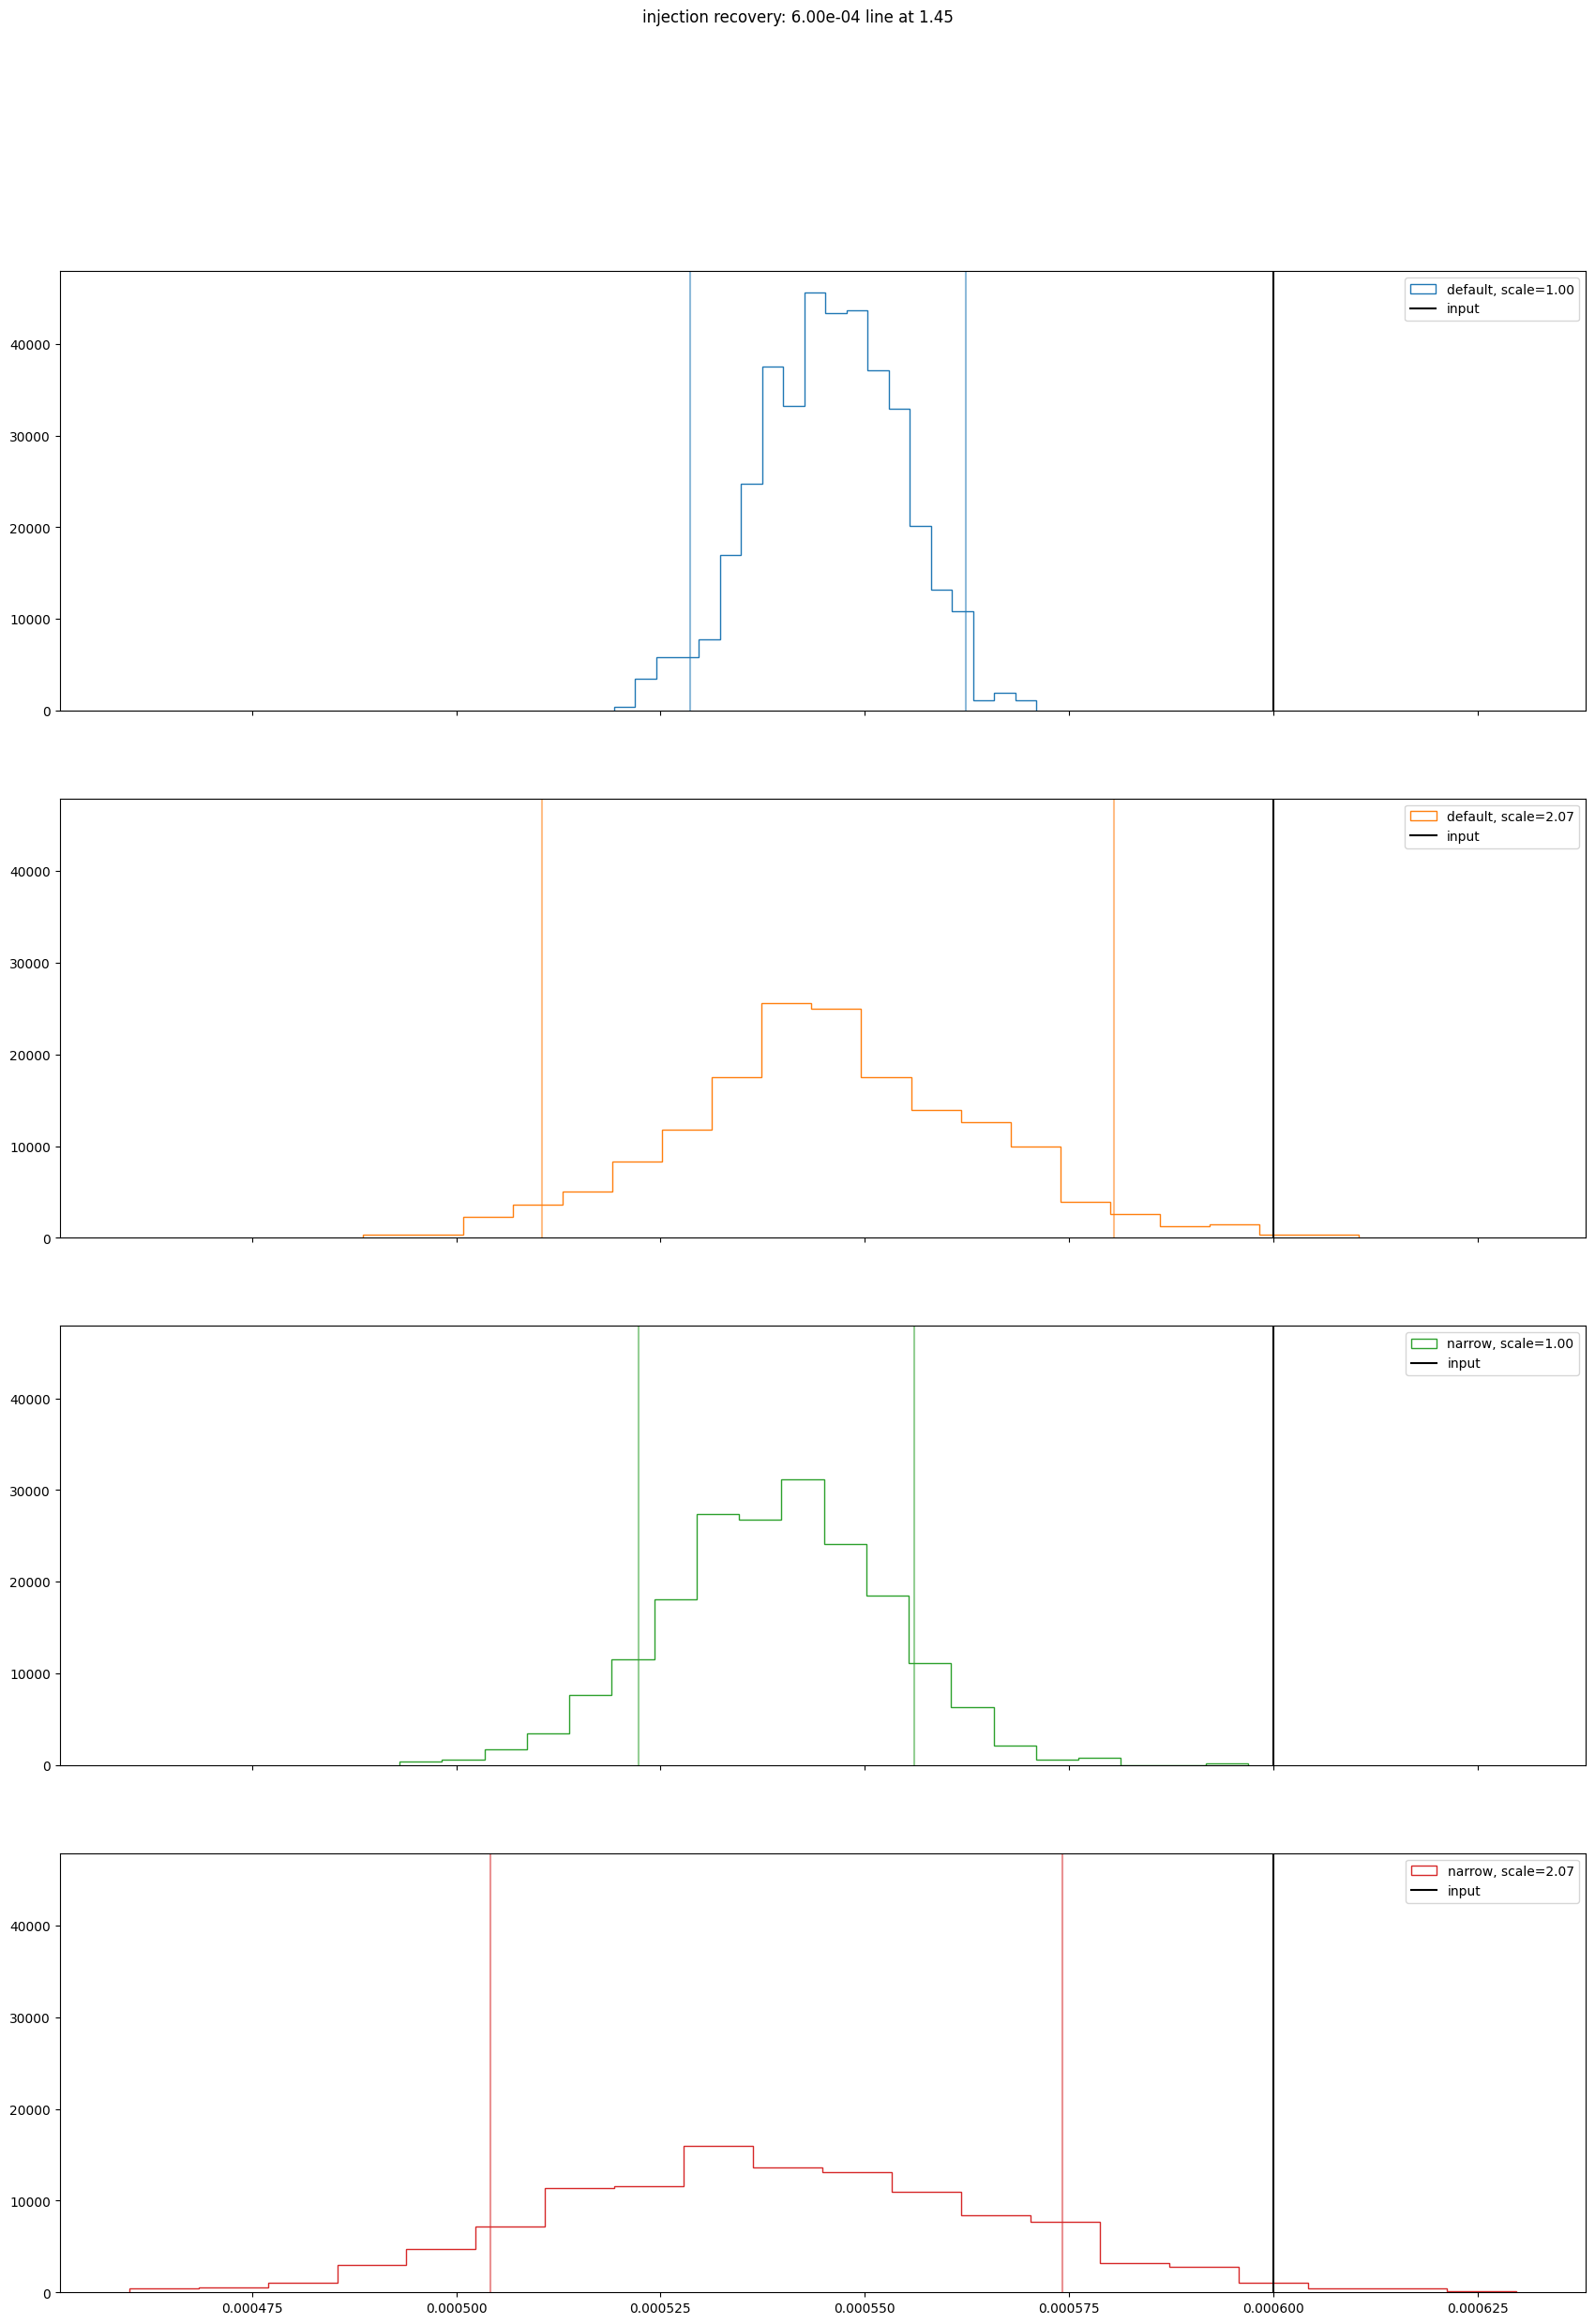

In [26]:
fig, axes = plt.subplots(len(setups)*error_scales.size,
                         sharex=True, sharey=True, 
                         figsize=(21, 4*7))
cmap = plt.get_cmap("tab10")
k = 0
for setup_name, bf_decayrates in bf_decayrates_dict.items():
    for i, scale_factor in enumerate(error_scales):
        axes[k].hist(bf_decayrates[:, i], bins=20, density=True, 
                     color=cmap(k), histtype='step', align='mid',
                     label=f"{setup_name}, scale={scale_factor:0.2f}")
        [axes[k].axvline(v, color=cmap(k), alpha=0.5) 
         for v in ci_dict[setup_name][i]]
        axes[k].axvline(decayrate, color='black', 
                        linestyle='solid', label="input")
        inside = ((ci_dict[setup_name][i][0] < bf_decayrates[:, i]) &
                  (bf_decayrates[:, i] < ci_dict[setup_name][i][1]))
        frac = np.sum(inside)/bf_decayrates.shape[0]
        print(f"{setup_name}, scale {scale_factor:.2f},\n"
              f"  frac inside ci: {100*frac:.2f}%\n")
        axes[k].legend()
        k += 1
fig.suptitle(f"injection recovery: {decayrate:.2e} line at {lam0}")

# Depdence on input g

In [34]:
decayrate_lims = 1e-6, 5e-3
lam0 = 2.1 #1.45
steps = 20
n_trials = 5*10**2

searcher = dmd.linesearch.LineSearcher(narrow_setup, new_specset, lam0)
eg_knot_vals = searcher.fit_continuum()
chisq_dof = searcher.chisq(eg_knot_vals, 0)/searcher.dof_continuum_only

decayrates = np.geomspace(*decayrate_lims, steps)
output = np.full(steps, np.nan)
std_output = np.full(steps, np.nan)
for i, dr in tqdm(enumerate(decayrates), total=steps):
     hold = np.full(n_trials, np.nan)
     for j in range(n_trials):
          trial_specset = base_specset.add_DM_line(dr, lam0)\
                                   .rescale_error(np.sqrt(chisq_dof))\
                                   .resample_flux()
          searcher = dmd.linesearch.LineSearcher(narrow_setup, trial_specset, lam0)
          _, hold[j] = searcher.fit_continuum_plus_line()
     quants = np.quantile(hold, [0.025, 0.5, 0.975])
     output[i] = quants[1]
     std_output[i] = (quants[2] - quants[0])/2
          

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [14:34<00:00, 43.72s/it]


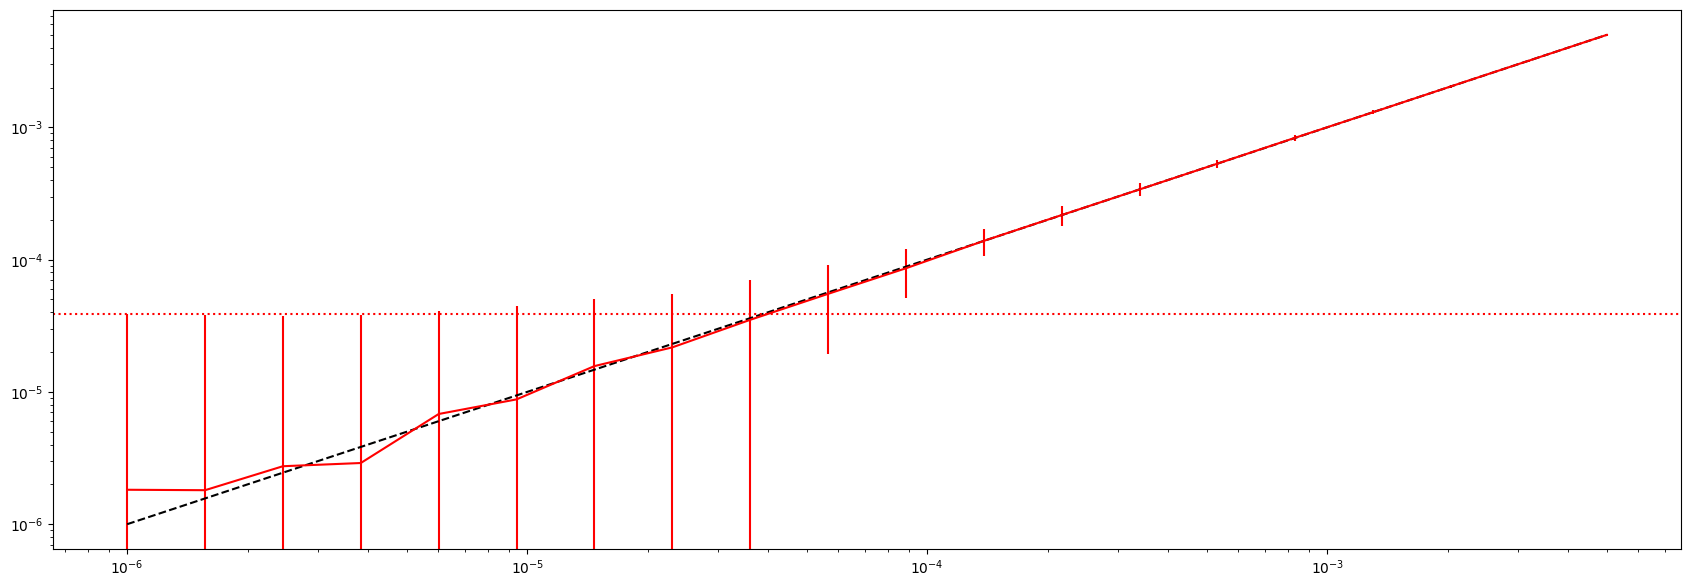

In [35]:
fig, ax = plt.subplots(figsize=(21, 7))
ax.errorbar(decayrates, output, yerr=std_output, color='red')
ax.plot(decayrates, decayrates, linestyle='dashed', color='black')
ax.set_xscale('log')
ax.set_yscale('log')

ax.axhline(output[0] + std_output[0], color='red', linestyle='dotted')